In [5]:
import os

print(os.listdir('/content'))

['.config', 'archive (1) (1).zip', 'sample_data']


In [6]:
import zipfile

with zipfile.ZipFile('/content/archive (1) (1).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/sign_data')

print("Extracted Successfully!")

Extracted Successfully!


In [7]:
import os

print(os.listdir('/content/sign_data'))

['sign_mnist_train.csv', 'sign_mnist_test', 'american_sign_language.PNG', 'amer_sign3.png', 'amer_sign2.png', 'sign_mnist_test.csv', 'sign_mnist_train']


In [8]:
#load data set
import pandas as pd

train_df = pd.read_csv('/content/sign_data/sign_mnist_train.csv')
test_df = pd.read_csv('/content/sign_data/sign_mnist_test.csv')

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (27455, 785)
Test Shape: (7172, 785)


In [9]:
#prepare data
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']

X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

print(X_train.shape)
print(X_test.shape)

(27455, 784)
(7172, 784)


In [10]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [11]:
#train svm
from sklearn.svm import SVC

X_train_small = X_train[:5000]
y_train_small = y_train[:5000]

model = SVC(kernel='rbf')

model.fit(X_train_small, y_train_small)

print("Model Training Completed!")

Model Training Completed!


In [12]:
#accuracy
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8025655326268823


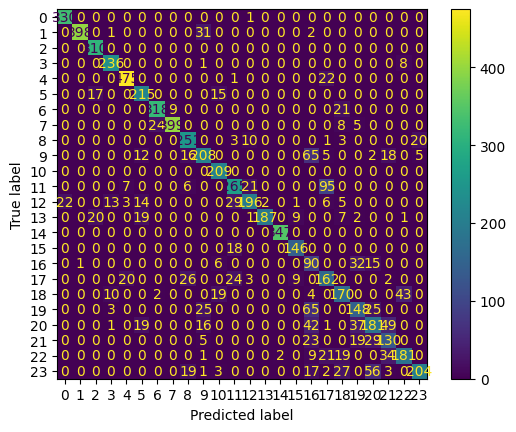

In [13]:
#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

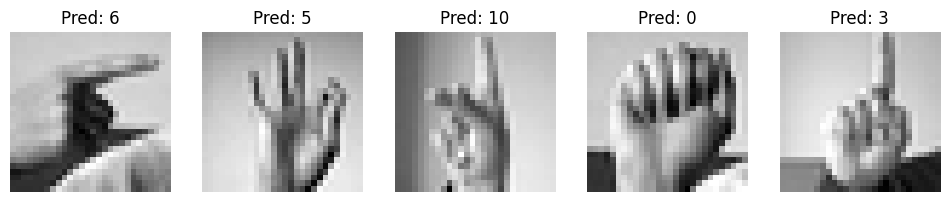

In [14]:
#prediction
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test.iloc[i].values.reshape(28,28), cmap='gray')
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis('off')

plt.show()